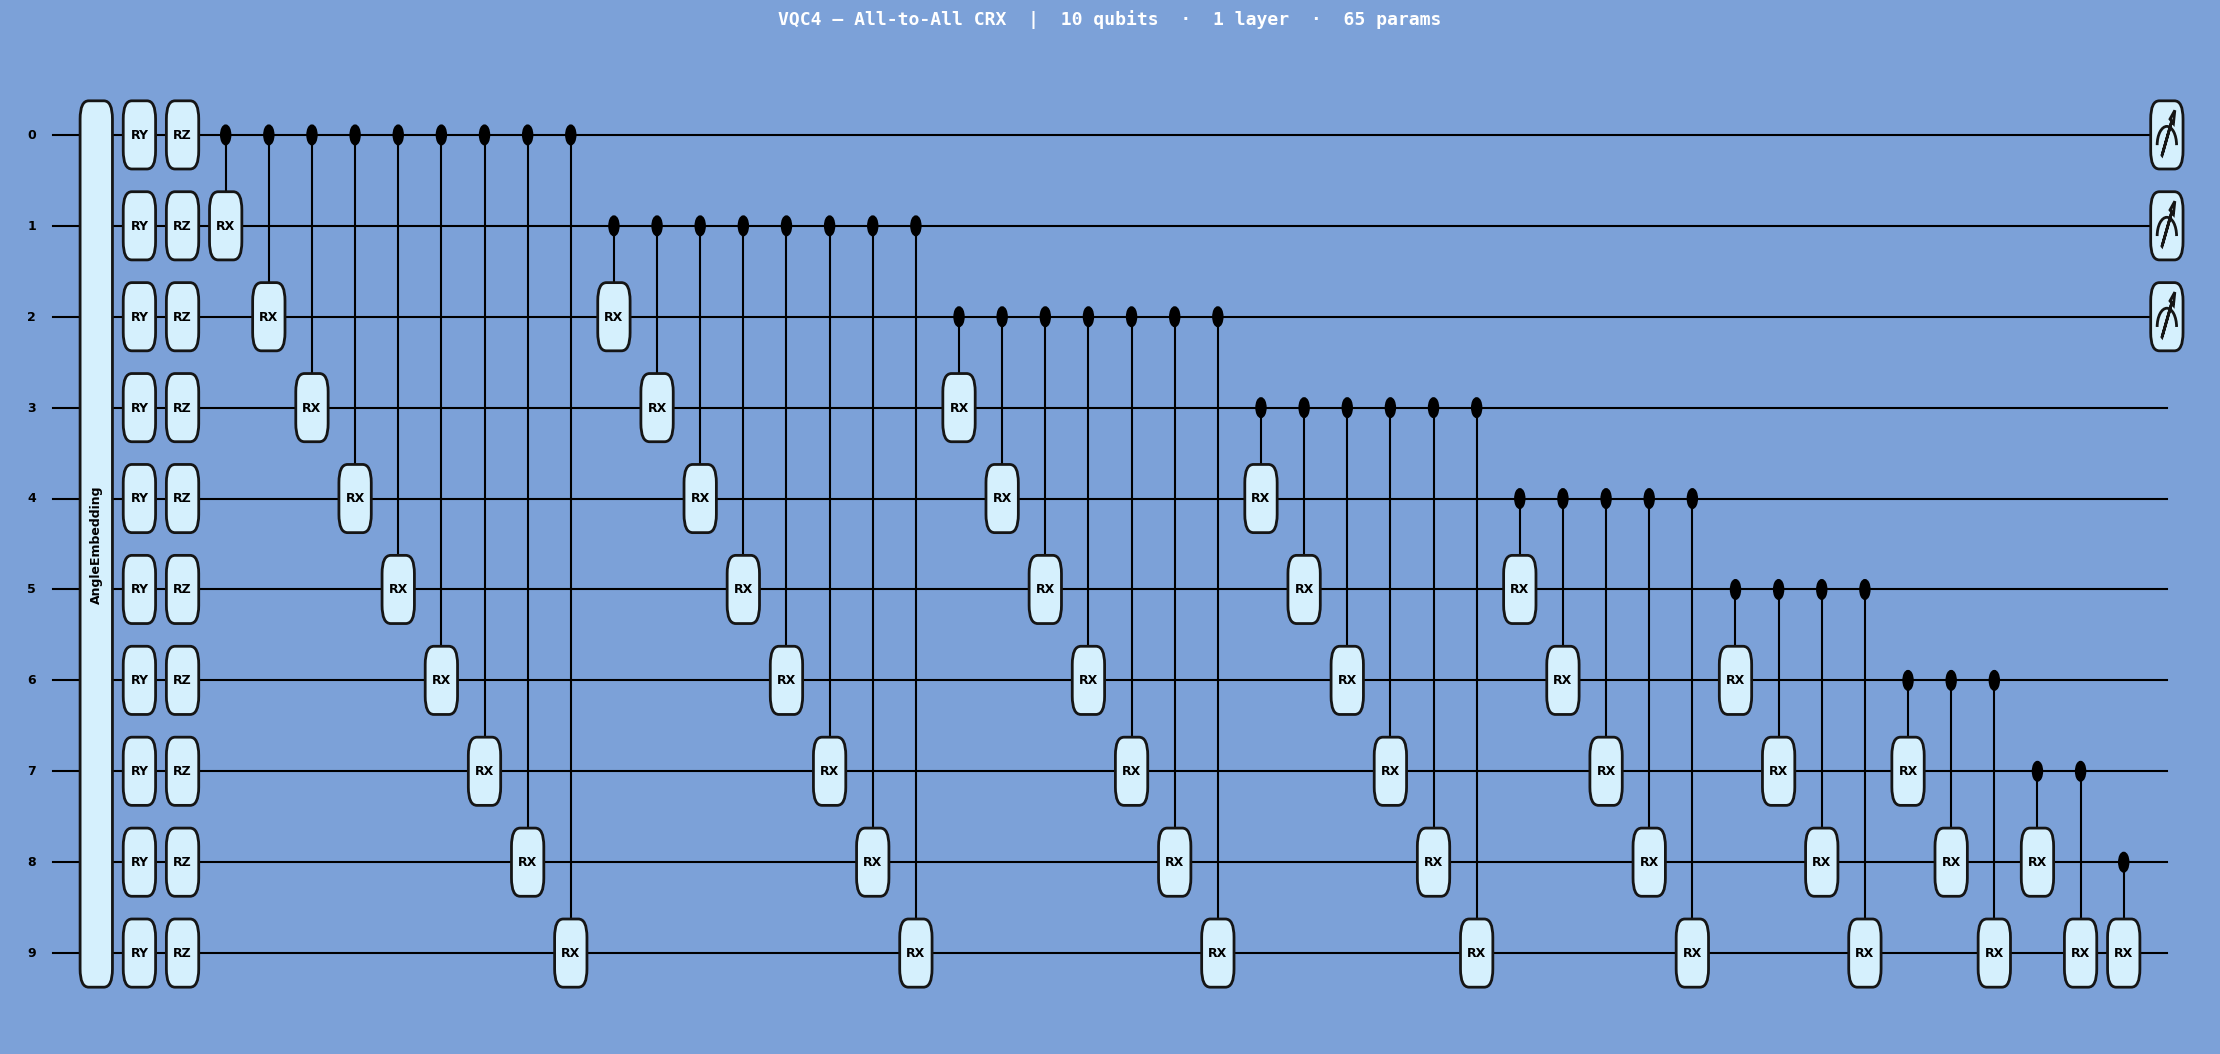

In [6]:
import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

# ── circuit definition ────────────────────────────────────────────
n_qubits         = 10
N_LAYERS         = 1                                  # set to 3 for full model
N_PAIRS          = (n_qubits * (n_qubits - 1)) // 2  # 45
PARAMS_PER_LAYER = 2 * n_qubits + N_PAIRS             # 65

dev = qml.device("default.qubit", wires=n_qubits)

def angle_embedding(x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation="Y")

def variational_layer(theta_layer):
    for i in range(n_qubits):
        qml.RY(theta_layer[i],            wires=i)
        qml.RZ(theta_layer[n_qubits + i], wires=i)
    crx_offset = 2 * n_qubits
    idx = 0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            qml.CRX(theta_layer[crx_offset + idx], wires=[i, j])
            idx += 1

@qml.qnode(dev, interface="autograd")
def quantum_circuit(x, theta):
    for layer in range(N_LAYERS):
        angle_embedding(x)
        variational_layer(theta[layer])
    return qml.math.stack([
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1)),
        qml.expval(qml.PauliZ(2)),
    ])

# ── draw ──────────────────────────────────────────────────────────
x_dummy     = np.zeros(n_qubits)
theta_dummy = np.zeros((N_LAYERS, PARAMS_PER_LAYER))

fig, ax = qml.draw_mpl(
    quantum_circuit,
    decimals=None,
    style="pennylane",          # clean dark-teal PennyLane style
    wire_order=list(range(n_qubits)),
    show_all_wires=True,
    fontsize=9,
)(x_dummy, theta_dummy)

fig.set_size_inches(22, 10)
fig.patch.set_facecolor("#7CA1D8")
ax.set_facecolor("#91b1e0")

ax.set_title(
    "VQC4 — All-to-All CRX  |  10 qubits  ·  1 layer  ·  65 params",
    fontsize=13, color="white", fontweight="bold", pad=14,
    fontfamily="monospace",
)

plt.savefig("vqc4_circuit.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()